In [20]:
import pandas as pd
import matplotlib.pyplot as plt

In [21]:
data=pd.read_csv("insurance.csv")

In [22]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [23]:
data.shape

(1338, 7)

In [24]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [25]:
data.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [26]:
data.duplicated().sum()

np.int64(1)

In [27]:
data.drop_duplicates(inplace=True)

In [28]:
data.age.min()

18

In [29]:
data.age.max()

64

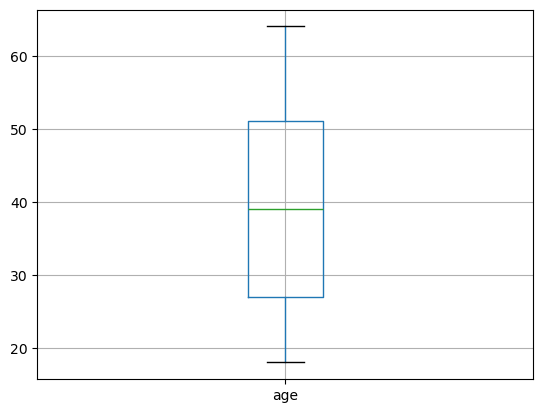

In [30]:
data.boxplot("age")
plt.show()

In [31]:
data.sex=data.sex.apply(lambda x: 1 if x=="male" else 0)

In [32]:
data.sex.value_counts()

sex
1    675
0    662
Name: count, dtype: int64

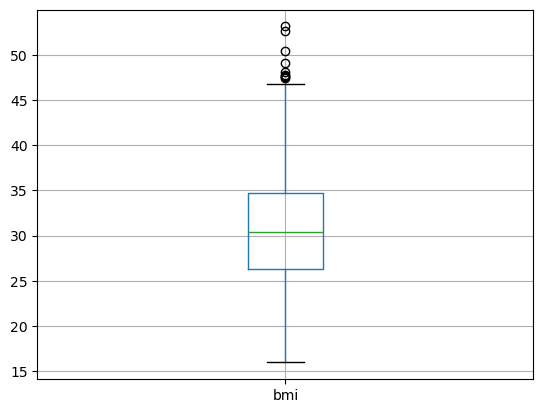

In [33]:
data.boxplot("bmi")
plt.show()

In [34]:
data.bmi.describe()

count    1337.000000
mean       30.663452
std         6.100468
min        15.960000
25%        26.290000
50%        30.400000
75%        34.700000
max        53.130000
Name: bmi, dtype: float64

In [35]:
Q1=data.bmi.quantile(0.25)
Q3=data.bmi.quantile(0.75)

IQR=Q3 -Q1

lower=Q1 - 1.5 * IQR
upper=Q3 + 1.5 * IQR

In [36]:
lower 

np.float64(13.674999999999994)

In [37]:
upper

np.float64(47.31500000000001)

In [38]:
data.bmi= data.bmi.clip(lower=lower,upper=upper)

In [39]:
data.smoker=data.smoker.apply(lambda x: 1 if x=="male" else 0)

In [40]:
data.region.unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

In [44]:
# we can do this,For datas like categorical ,but it is lenthy
dummy=pd.get_dummies(data.region,dtype=int)
encoded_data=pd.concat([data,dummy],axis=1).drop("region",axis=1)

In [42]:
# We can do this work through scikit learn
from sklearn.preprocessing import OneHotEncoder    #,LabelEncoder  # Labels are known as y(predictions), in machine learning.So Label encoding is of pred. 

In [47]:
ohe=OneHotEncoder()
encoded_region=ohe.fit_transform(data[["region"]])

In [51]:
encoded_region=encoded_region.toarray()

In [92]:
df=pd.read_csv("insurance.csv")

In [49]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [50]:
pd.get_dummies(df,dtype=int)

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,1,0,0,1,0,0,0,1
1,18,33.770,1,1725.55230,0,1,1,0,0,0,1,0
2,28,33.000,3,4449.46200,0,1,1,0,0,0,1,0
3,33,22.705,0,21984.47061,0,1,1,0,0,1,0,0
4,32,28.880,0,3866.85520,0,1,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,30.970,3,10600.54830,0,1,1,0,0,1,0,0
1334,18,31.920,0,2205.98080,1,0,1,0,1,0,0,0
1335,18,36.850,0,1629.83350,1,0,1,0,0,0,1,0
1336,21,25.800,0,2007.94500,1,0,1,0,0,0,0,1


### An Example For Explaination:

In [1]:
from sklearn.preprocessing import OneHotEncoder
enc=OneHotEncoder(handle_unknown="ignore")    # Handle unknown "ignore" can ignore those categories or columns that are not present at training time.

In [3]:
X=[["Male",1],["Female",3],["Female",2]]

In [4]:
enc.fit(X)

,categories,'auto'
,drop,None
,sparse_output,True
,dtype,<class 'numpy.float64'>
,handle_unknown,'ignore'
,min_frequency,None
,max_categories,None
,feature_name_combiner,'concat'


In [5]:
enc.categories_

[array(['Female', 'Male'], dtype=object), array([1, 2, 3], dtype=object)]

In [9]:
enc.transform([["Female",1],["Male",4]]).toarray()

array([[1., 0., 1., 0., 0.],
       [0., 1., 0., 0., 0.]])

In [13]:
enc.inverse_transform([[0,1,1,0,0],[0,0,0,1,0]])

array([['Male', 1],
       [None, 2]], dtype=object)

In [14]:
enc.get_feature_names_out(["gender","group"])  # we gives the feature names them

array(['gender_Female', 'gender_Male', 'group_1', 'group_2', 'group_3'],
      dtype=object)

In [15]:
drop_enc=OneHotEncoder(drop="first").fit(X) #drop first can drop the column from which we can make the categories encoding.

In [17]:
drop_enc.categories_

[array(['Female', 'Male'], dtype=object), array([1, 2, 3], dtype=object)]

In [18]:
drop_enc.transform([["Female",1],["Male",2]]).toarray()

array([[0., 0., 0.],
       [1., 1., 0.]])

### Practical Example:

In [93]:
from sklearn.preprocessing import OneHotEncoder
ohe=OneHotEncoder()

In [94]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [95]:
ohe.fit(df[["sex","smoker","region"]])

,categories,'auto'
,drop,None
,sparse_output,True
,dtype,<class 'numpy.float64'>
,handle_unknown,'error'
,min_frequency,None
,max_categories,None
,feature_name_combiner,'concat'


In [96]:
df_transform=ohe.transform(df[["sex","smoker","region"]]).toarray()

In [97]:
df_transform

array([[1., 0., 0., ..., 0., 0., 1.],
       [0., 1., 1., ..., 0., 1., 0.],
       [0., 1., 1., ..., 0., 1., 0.],
       ...,
       [1., 0., 1., ..., 0., 1., 0.],
       [1., 0., 1., ..., 0., 0., 1.],
       [1., 0., 0., ..., 1., 0., 0.]], shape=(1338, 8))

In [98]:
pd.DataFrame(data=df_transform,columns=ohe.get_feature_names_out())

,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
2,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
3,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
4,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...
1333,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
1334,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
1335,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1336,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


In [99]:
ohe.get_feature_names_out()

array(['sex_female', 'sex_male', 'smoker_no', 'smoker_yes',
       'region_northeast', 'region_northwest', 'region_southeast',
       'region_southwest'], dtype=object)

In [100]:
transformed_df=pd.concat([df,pd.DataFrame(data=df_transform,columns=ohe.get_feature_names_out())],axis=1)

In [101]:
transformed_df.drop(["sex","smoker","region"],axis=1,inplace=True)

In [103]:
transformed_df.isna().sum()

age                 0
bmi                 0
children            0
charges             0
sex_female          0
sex_male            0
smoker_no           0
smoker_yes          0
region_northeast    0
region_northwest    0
region_southeast    0
region_southwest    0
dtype: int64

In [105]:
X=transformed_df.drop("charges",axis=1)
y=transformed_df.charges

In [108]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.30,random_state=123)

In [109]:
from sklearn.linear_model import LinearRegression

In [110]:
model=LinearRegression()

In [111]:
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [113]:
y_pred_train=model.predict(X_train)

In [114]:
y_pred_test=model.predict(X_test)

In [115]:
from sklearn.metrics import r2_score

In [116]:
r2_score(y_train,y_pred_train)

0.7455786454653719

In [117]:
r2_score(y_test,y_pred_test)

0.7627582187528819